@author: João Mello

In [1]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, \
    StratifiedKFold
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
import pickle

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

In [4]:
# load data
titanic = pd.read_pickle('/home/usp-ds-arnem/data/aula4/titanic1.pkl')
X = titanic.drop(columns='survived')
y=titanic.survived
#%% Dividir os dados em treino e teste (holdout)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [5]:
# hyper parameters

param_dist = {
    'n_estimators': [50, 100, 200, 300],  # Número de árvores
    'max_depth': range(2, 30, 1),      # Profundidade máxima das árvores
    'min_samples_split': [2, 5, 10],      # Número mínimo de amostras para dividir um nó
    'min_samples_leaf': [1, 2, 4],        # Número mínimo de amostras em uma folha
    'max_features': ['sqrt', 'log2', None],  # Número de features consideradas para divisão
    'bootstrap': [True, False],           # Usar bootstrap ou não
    'criterion': ['gini', 'entropy'],     # Critério de divisão
    'ccp_alpha': np.linspace(0, 0.05, 20)  # Parâmetro de poda de complexidade de custo
}

In [6]:
# Number os possibilities
4*30*3*3*3*2*2*20

259200

In [7]:
n_iter = 50  # Número de combinações de hiperparâmetros a serem testadas
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-Fold estratificado
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=n_iter,
    cv=kf,
    scoring='roc_auc',
    n_jobs=-1,  
    verbose=1,  
    random_state=42
)

In [8]:
start_time = time.time()
random_search.fit(X_train, y_train)
# Parar o cronômetro
end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nMelhores hiperparâmetros: {random_search.best_params_}")
print(f"\nAUC média na validação cruzada: {random_search.best_score_:.4f}")
print(f"\nTempo total de execução: {elapsed_time:.2f} segundos")


Fitting 5 folds for each of 50 candidates, totalling 250 fits

Melhores hiperparâmetros: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'criterion': 'entropy', 'ccp_alpha': 0.018421052631578946, 'bootstrap': False}

AUC média na validação cruzada: 0.8699

Tempo total de execução: 14.47 segundos


In [9]:
# Modelo com os melhores parametros
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
random_roc = roc_auc_score(y_test, y_proba)
random_gini = random_roc * 2 - 1
print(f"\nAUC no teste: {random_roc:.4f}")
print(f"\nGini no teste: {random_gini:.4f}")


AUC no teste: 0.8549

Gini no teste: 0.7099


In [10]:
# Resgatar o modelo anterior
with open('/home/usp-ds-arnem/data/aula4/best_clf.pkl', 'rb') as file:
    best_clf = pickle.load(file)

In [11]:
# Verificar se o modelo suporta predict_proba (caso contrário, usar a decisão bruta)
if hasattr(best_clf, "predict_proba"):
    y_scores = best_clf.predict_proba(X_test)[:, 1]  # Probabilidades da classe positiva
else:
    y_scores = best_clf.decision_function(X_test)  # Alternativa se não houver predict_proba


In [12]:
# Calcular a AUC
auc_score = roc_auc_score(y_test, y_scores)
gini = auc_score*2-1
print(f"gini na base de teste da árvore: {gini:.4f}")

gini na base de teste da árvore: 0.7479


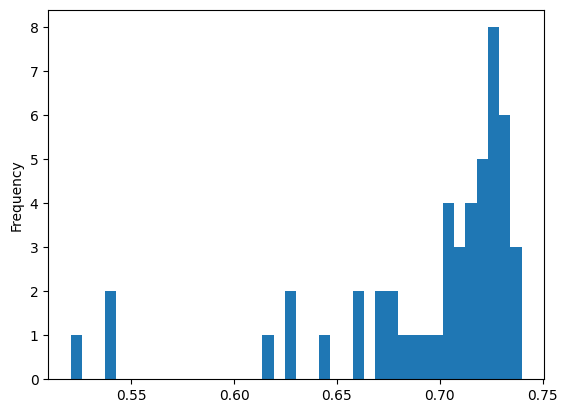

In [13]:
# Avaliando os resultados do tunning
resultados = pd.DataFrame(random_search.cv_results_)
resultados['gini'] = resultados.mean_test_score*2-1
resultados.gini.plot.hist(bins=40)
plt.show()

### Bayesian search

In [14]:
param_space = {
    'n_estimators': Integer(50, 300),
    'max_depth': Integer(1, 50),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 4),
    'max_features': Categorical(['sqrt', 'log2', None]),
    'bootstrap': Categorical([True, False]),
    'criterion': Categorical(['gini', 'entropy']),
    'ccp_alpha': Real(0, 0.05)
}

n_iter=20
bayes_search = BayesSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    search_spaces=param_space,
    n_iter=n_iter,  # Número de iterações
    cv=5,       # 5-Fold Cross-Validation
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

In [15]:
# Iniciar o cronômetro
start_time = time.time()
bayes_search.fit(X_train, y_train)
# Parar o cronômetro
end_time = time.time()
elapsed_time = end_time - start_time

# Resultados da busca
print(f"Melhores hiperparâmetros: {bayes_search.best_params_}")
print(f"\nAUC média na validação cruzada: {bayes_search.best_score_:.2%}")
print(f"\nTempo total de execução: {elapsed_time:.2f} segundos")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [17]:
final_clf = bayes_search.best_estimator_

In [18]:
# Avaliar no conjunto de teste
bayes_test_score = final_clf.score(X_test, y_test)
bayes_roc = roc_auc_score(y_test, final_clf.predict_proba(X_test)[:,1])
bayes_gini = bayes_roc*2-1
print(f"Gini do bayesian search no teste: {bayes_gini:.4f}")

Gini do bayesian search no teste: 0.7190


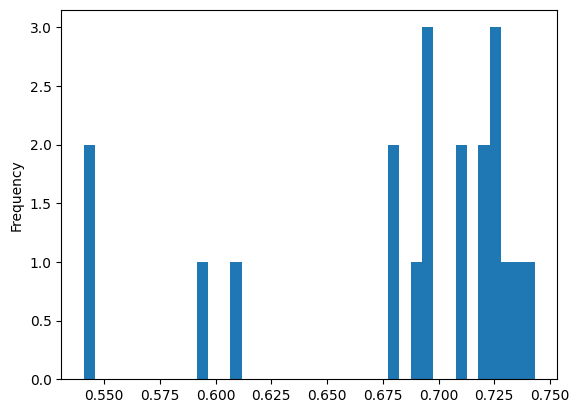

In [19]:
resultados_bayes = pd.DataFrame(bayes_search.cv_results_)
resultados_bayes['gini'] = resultados_bayes.mean_test_score*2-1
resultados_bayes.gini.plot.hist(bins=40)
plt.show()